In [5]:
import pandas as pd

df = pd.read_csv("ecommerce_dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
print(df.head())
print(df.columns)
print(df.dtypes)

   order_id product     category     price  quantity payment_method  \
0         1   Watch  Electronics  12652.30         4      Easypaisa   
1         2     Bag      Fashion  20053.64         2    Credit Card   
2         3   Shoes      Fashion  13274.17         2       JazzCash   
3         4     Bag  Electronics  15332.08         1            COD   
4         5     Bag  Accessories  23165.07         1     Debit Card   

         date     total    Month  Discount  City Code  Order Priority Code  \
0  01/01/2023  50609.20  January       0.0        1.0                  2.0   
1  02/01/2023  40107.28  January       0.1        1.0                  2.0   
2  03/01/2023  26548.34  January       0.1        1.0                  2.0   
3  04/01/2023  15332.08  January       0.1        1.0                  2.0   
4  05/01/2023  23165.07  January       0.0        1.0                  NaN   

   Latitude  Longtitude  
0       1.0         0.0  
1       1.0         0.0  
2       1.0         0.0  


In [7]:
df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
}, inplace=True)

In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
Latitude           0
Longtitude         0
dtype: int64

In [11]:
df["total"].fillna(df["total"].median(), inplace=True)

C:\Users\KASHIF\AppData\Local\Temp\ipykernel_11864\10576195.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total"].fillna(df["total"].median(), inplace=True)


In [ ]:
import os
print(os.listdir())


['.git', 'assignment1-ii.ipynb', 'assignment10', 'assignment10.ipynb', 'assignment11.ipynb', 'assignment12.ipynb', 'assignment13.ipynb', 'assignment4.ipynb', 'assignment5.ipynb', 'assignment6.ipynb', 'assignment8.ipynb', 'assignment9.ipynb', 'cars.csv', 'cars_no_duplicates.csv', 'ecommerce_dataset.csv', 'quiz app.ipynb', 'retail supermarket (1).csv', 'supermarke.csvassignment10', 'supermarket.csv', 'titanic_dataset.csv']


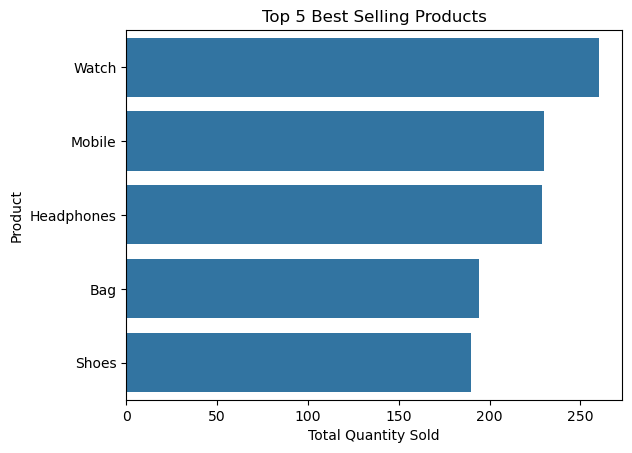

In [26]:
top5 = df.groupby('product')['quantity'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top5.values, y=top5.index)
plt.title("Top 5 Best Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()


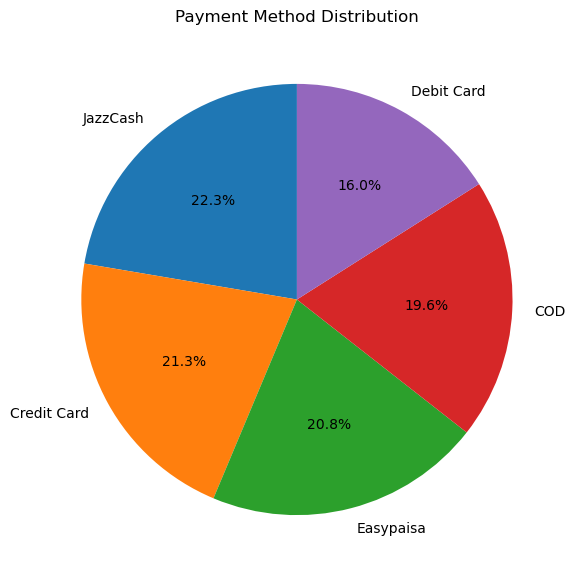

In [ ]:
payment = df['payment_method'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    payment.values,
    labels=payment.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Payment Method Distribution")
plt.show()


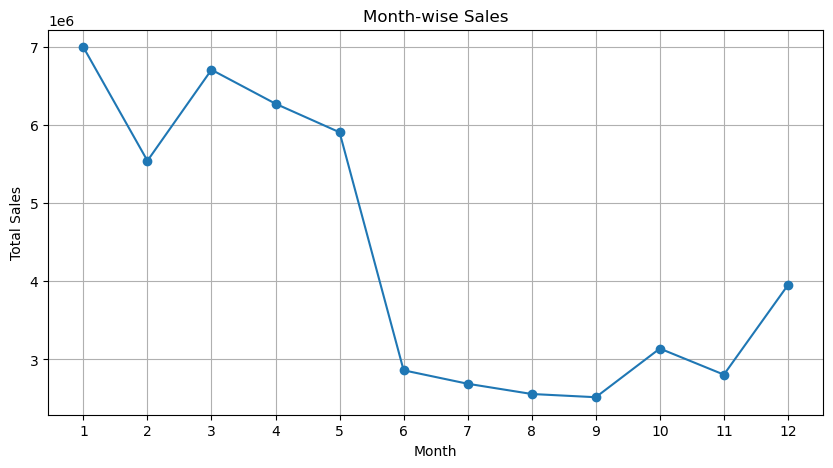

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df['total_sales'] = df['price'] * df['quantity']
df['Month'] = df['date'].dt.month
monthly_sales = df.groupby('Month')['total_sales'].sum()
plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)
plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid()
plt.show()


In [ ]:
monthly_sales = df.groupby('Month')['total'].sum()
print(monthly_sales)


Month
1     6999686.85
2     5545040.22
3     6711119.66
4     6275753.74
5     5909845.92
6     2860920.11
7     2688475.62
8     2557288.54
9     2515916.08
10    3139444.82
11    2805153.37
12    3952563.75
Name: total, dtype: float64


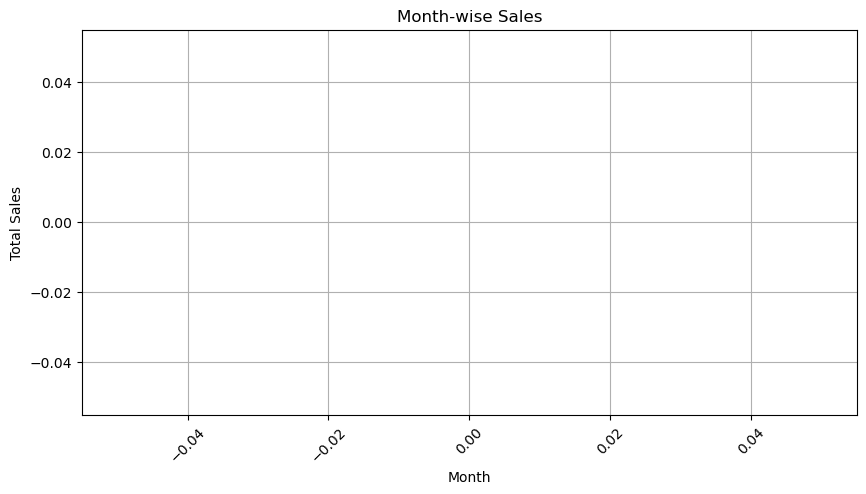

In [21]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
monthly_sales = df.groupby('Month')['total'].sum()
monthly_sales = monthly_sales.reindex(
    [m for m in month_order if m in monthly_sales.index]
)
plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)
plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()




In [22]:
city_mapping = {
    1: 'Karachi',
    2: 'Lahore',
    3: 'Islamabad',
    4: 'Peshawar',
    5: 'Quetta'
}
df['City'] = df['City Code'].map(city_mapping)


C:\Users\KASHIF\AppData\Local\Temp\ipykernel_17184\2776448368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


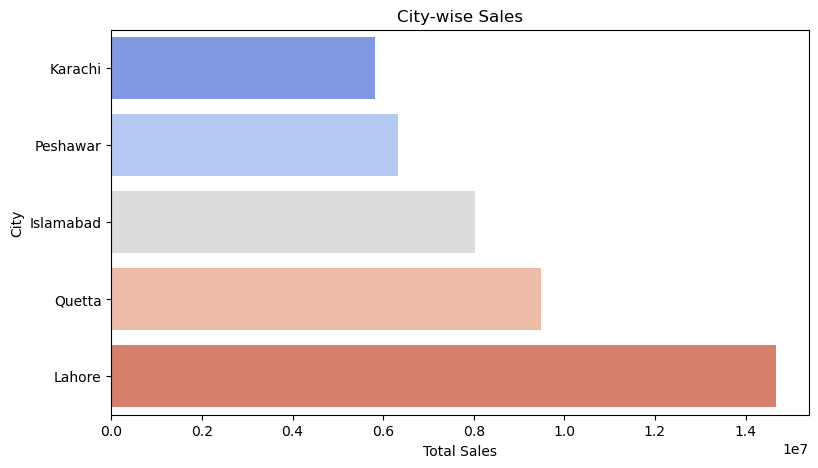

In [23]:
city_sales = df.groupby('City')['total'].sum().sort_values(ascending=True)
plt.figure(figsize=(9,5))
sns.barplot(
    x=city_sales.values,
    y=city_sales.index,
    palette='coolwarm'
)
plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()


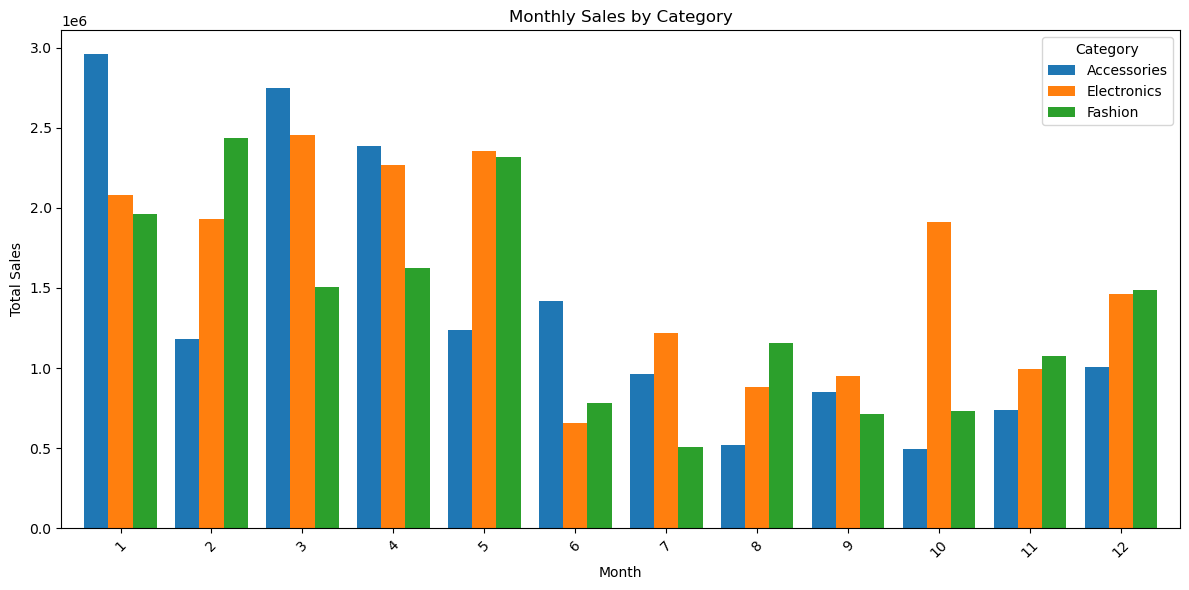

In [25]:
monthly_category = df.pivot_table(
    index='Month',
    columns='category',
    values='total',
    aggfunc='sum'
)
monthly_category.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8
)
plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.show()
